In [17]:
# Import all required libraries
import pandas as pd
import numpy as np
import pingouin as pg
from pathlib import Path
from glob import glob
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
import re

In [18]:
# Setup directories and plotting theme
data_dir = "dset"
#raw_annot_dir = op.join(data_dir, "annotations")
deriv_dir = op.join(data_dir, "derivatives")
raw_annot_dir = op.join(data_dir, "annotations")

# # Create directories
# OUT_DIR.mkdir(parents=True, exist_ok=True)
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting theme
sns.set_theme(style="darkgrid")

# Define colors for consistent plotting
colors = ["#11FF00", "#FF0800", "#F6FF00", "#FF00CC", "#0400FF", "#00eeff", '#e377c2', '#BCB5BB']

In [19]:
episode_numbers = [1, 2, 3, 4]
run_numbers = range(0, 8)

episode_csvs = {}

for ep_num in episode_numbers:
    episode_key = f"S01E{ep_num:02d}"
    episode_dir = op.join(raw_annot_dir, episode_key)

    run_csvs = {}
    for i in run_numbers:
        run_key = f"R0{i}"
        csv_pattern = op.join(episode_dir, f"{episode_key}{run_key}*.csv")
        csv_files = sorted(glob(csv_pattern))
        if csv_files:
            run_csvs[run_key] = csv_files

    episode_csvs[episode_key] = run_csvs

    print(f"{episode_key}: {len(run_csvs)} runs with CSVs")
    for run_key, files in run_csvs.items():
        print(f"  {run_key}: {len(files)} CSV files")
        for file_path in files:
            rater_df = pd.read_csv(file_path)
            print(f"    {op.basename(file_path)} -> {rater_df.shape}")
            
    print()

S01E01: 6 runs with CSVs
  R01: 4 CSV files
    S01E01R01_002.csv -> (334, 3)
    S01E01R01_003.csv -> (334, 3)
    S01E01R01_005.csv -> (334, 3)
    S01E01R01_008.csv -> (334, 3)
  R02: 5 CSV files
    S01E01R02_001.csv -> (276, 3)
    S01E01R02_002.csv -> (276, 3)
    S01E01R02_003.csv -> (276, 3)
    S01E01R02_004.csv -> (276, 3)
    S01E01R02_008.csv -> (276, 3)
  R03: 3 CSV files
    S01E01R03_004.csv -> (275, 3)
    S01E01R03_005.csv -> (275, 3)
    S01E01R03_006.csv -> (275, 3)
  R04: 3 CSV files
    S01E01R04_001.csv -> (286, 3)
    S01E01R04_005.csv -> (286, 3)
    S01E01R04_008.csv -> (286, 3)
  R05: 4 CSV files
    S01E01R05_003.csv -> (312, 3)
    S01E01R05_005.csv -> (312, 3)
    S01E01R05_006.csv -> (312, 3)
    S01E01R05_008.csv -> (312, 3)
  R06: 4 CSV files
    S01E01R06_003.csv -> (333, 3)
    S01E01R06_005.csv -> (333, 3)
    S01E01R06_006.csv -> (333, 3)
    S01E01R06_008.csv -> (333, 3)

S01E02: 7 runs with CSVs
  R01: 3 CSV files
    S01E02R01_004.csv -> (313, 3)


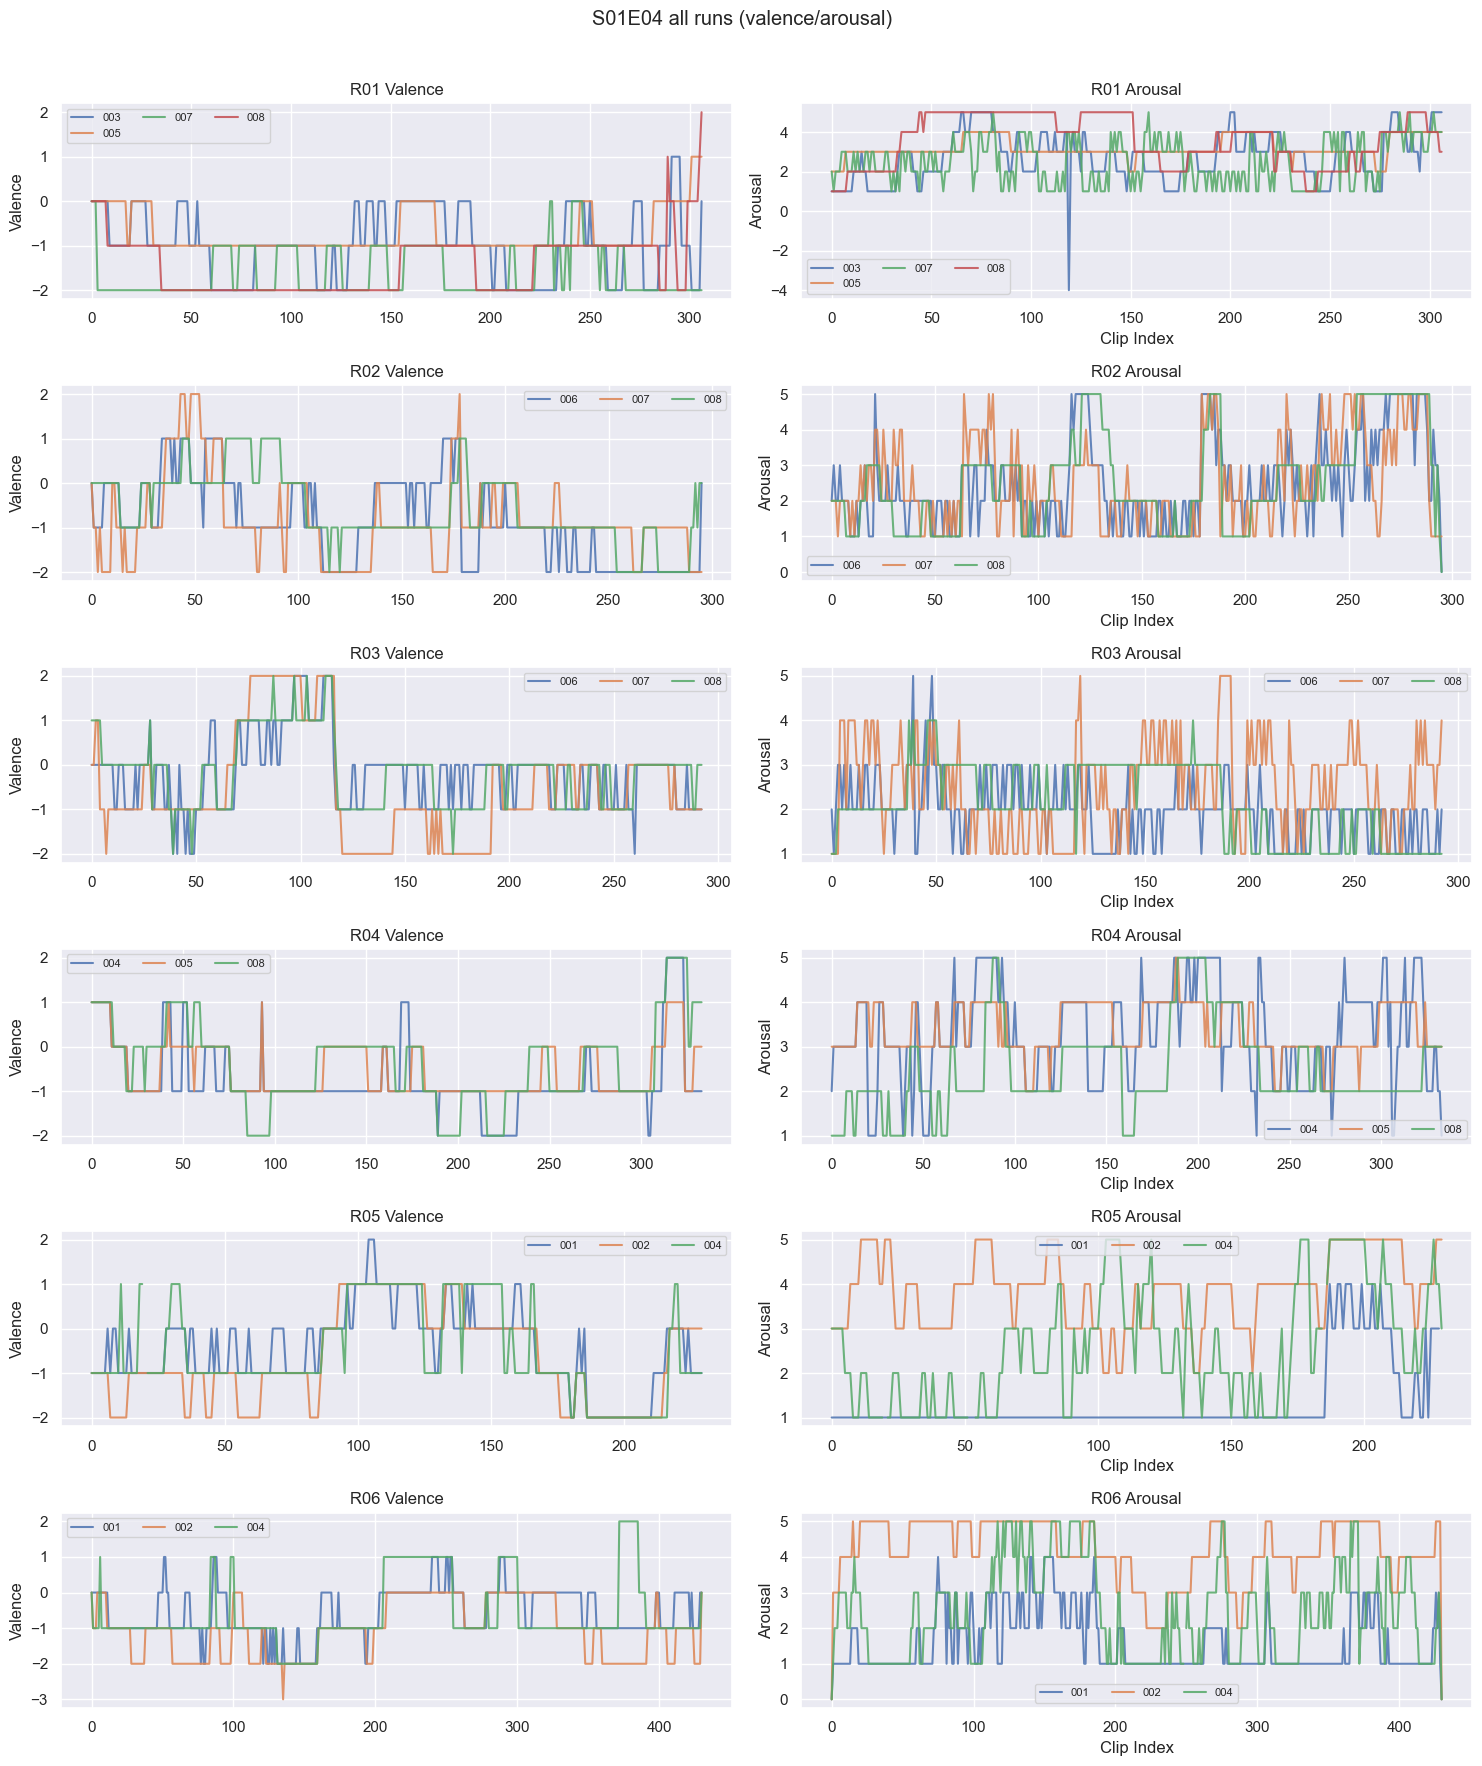

In [ ]:
episode_to_plot = "S01E04"
runs_to_plot = ["R01", "R02", "R03", "R04", "R05", "R06"]

n_runs = len(runs_to_plot)
fig, axs = plt.subplots(n_runs, 2, figsize=(15, 3 * n_runs), sharex=False)
fig.suptitle(f"{episode_to_plot} all runs (valence/arousal)")

for i, run_to_plot in enumerate(runs_to_plot):
    run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
    if not run_files:
        continue

    ax_val = axs[i, 0]
    ax_aro = axs[i, 1]
    dfs_val = []
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")
        if val_col is None or aro_col is None:
            continue

        rater_label = op.basename(file_path).split("_")[-1].replace(".csv", "")
        values = pd.to_numeric(df[val_col], errors="coerce")
        aros = pd.to_numeric(df[aro_col], errors="coerce")
        times = np.arange(len(df))

        dfs_val.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "valence": values
        }))
        dfs_aro.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "arousal": aros
        }))

        ax_val.plot(values.to_numpy(), label=rater_label, alpha=0.85)
        ax_aro.plot(aros.to_numpy(), label=rater_label, alpha=0.85)

    icc_val = np.nan
    icc_aro = np.nan

    if dfs_val:
        long_df_val = pd.concat(dfs_val, ignore_index=True).dropna()
        if not long_df_val.empty:
            icc_result_val = pg.intraclass_corr(
                data=long_df_val,
                targets="time",
                raters="rater",
                ratings="valence",
                nan_policy="omit"
            )
            icc_val_series = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"]
            if not icc_val_series.empty:
                icc_val = float(icc_val_series.values[0])

    if dfs_aro:
        long_df_aro = pd.concat(dfs_aro, ignore_index=True).dropna()
        if not long_df_aro.empty:
            icc_result_aro = pg.intraclass_corr(
                data=long_df_aro,
                targets="time",
                raters="rater",
                ratings="arousal",
                nan_policy="omit"
            )
            icc_aro_series = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"]
            if not icc_aro_series.empty:
                icc_aro = float(icc_aro_series.values[0])

    ax_val.set_title(f"{run_to_plot} Valence (ICC2={icc_val:.3f})")
    ax_val.set_ylabel("Valence")
    ax_val.legend(fontsize=8, ncol=3)

    ax_aro.set_title(f"{run_to_plot} Arousal (ICC2={icc_aro:.3f})")
    ax_aro.set_ylabel("Arousal")
    ax_aro.set_xlabel("Clip Index")
    ax_aro.legend(fontsize=8, ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()